<a href="https://colab.research.google.com/github/arivine/data-science-2026/blob/main/Pertemuan_7_Muhammad_Arifin_230401010367.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###  Identitas Mahasiswa
* **Nama Lengkap:** Muhammad Arifin
* **NIM:** 230401010367
* **Kelas:** IF 401
* **Program Studi:** PJJ Informatika

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error,
mean_squared_error, r2_score)

β₀ (intercept): 18.776
β₁ (slope) : 9.308
MAE = 1.258
RMSE = 1.562
R² = 0.970


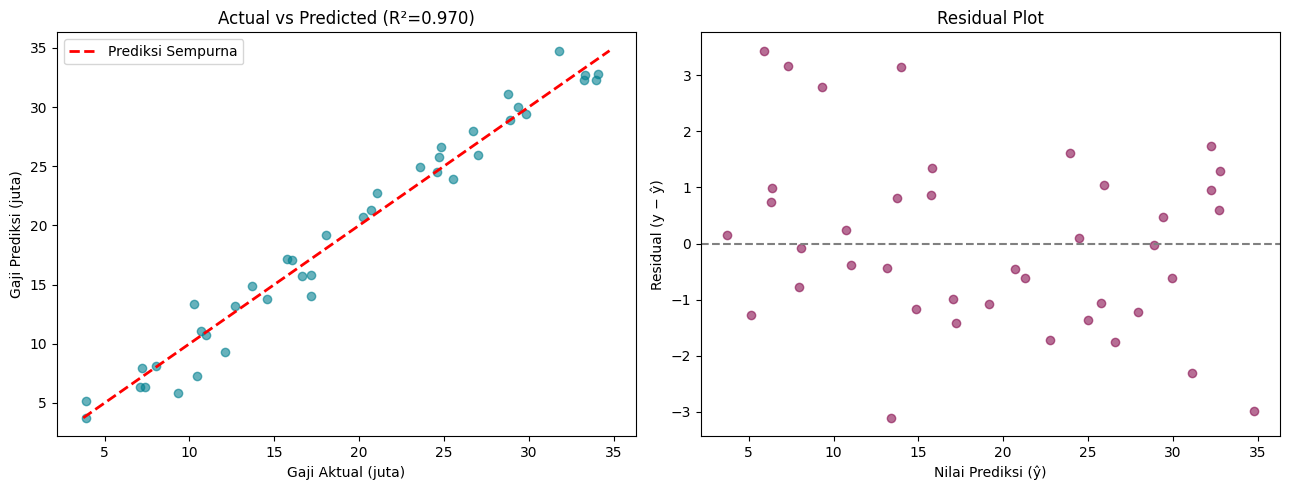

In [2]:
# ── 1. Load Data ────────────────────────────────────────────────
# Contoh: dataset Experience vs Salary
np.random.seed(42); n = 200
experience = np.random.uniform(0, 15, n)
salary = 3.5 + 2.1 * experience + np.random.normal(0, 1.5, n)
X = experience.reshape(-1, 1) # scikit-learn butuh 2D array
y = salary
# ── 2. Train-Test Split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)
# ── 3. Feature Scaling ──────────────────────────────────────────
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test) # hanya transform!
# ── 4. Fit Model ────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train_s, y_train)
print(f'β₀ (intercept): {model.intercept_:.3f}')
print(f'β₁ (slope) : {model.coef_[0]:.3f}')
# β₀ ≈ 11.0 (rata-rata gaji pada X ternormalisasi = 0)
# β₁ ≈ 7.4 (slope dalam satuan terstandarisasi)
# ── 5. Prediksi ─────────────────────────────────────────────────
y_pred = model.predict(X_test_s)
# ── 6. Evaluasi ─────────────────────────────────────────────────
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f'MAE = {mae:.3f}')
print(f'RMSE = {rmse:.3f}')
print(f'R² = {r2:.3f}')
# ── 7. Visualisasi Actual vs Predicted ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='#028090')
lims = [min(y_test.min(), y_pred.min()),
max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2,
label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta)')
axes[0].set_ylabel('Gaji Prediksi (juta)')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].legend()
# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='#880E4F')
axes[1].axhline(0, color='gray', linestyle='--', lw=1.5)
axes[1].set_xlabel('Nilai Prediksi (ŷ)')
axes[1].set_ylabel('Residual (y − ŷ)')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


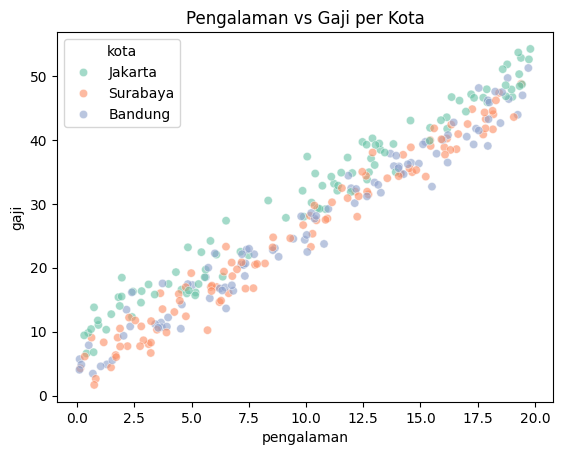

In [3]:
import matplotlib.pyplot as plt, seaborn as sns
# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
+ np.where(kota=='Jakarta', 4.0, 0)
+ np.random.normal(0, 2, n))
df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu,
'kota':kota, 'gaji':gaji})
# EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))
# Scatter: pengalaman vs gaji
sns.scatterplot(data=df, x='pengalaman', y='gaji',
hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.show()

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


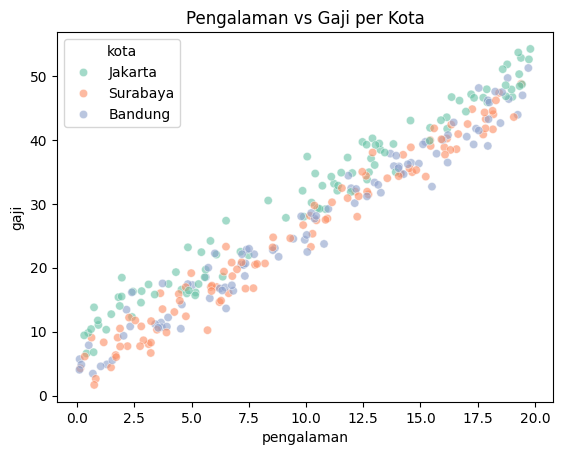

In [4]:
# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
+ np.where(kota=='Jakarta', 4.0, 0)
+ np.random.normal(0, 2, n))
df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu,
'kota':kota, 'gaji':gaji})
# EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))
# Scatter: pengalaman vs gaji
sns.scatterplot(data=df, x='pengalaman', y='gaji',
hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'],
drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())
# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')
# StandardScaler — fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


In [6]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_s, y_train)
# Tampilkan koefisien
print(f'β₀ (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
'Fitur' : X.columns,
'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

# Interpretasi: fitur mana yang paling berpengaruh?
# Koefisien positif → gaji naik
# Koefisien negatif → gaji turun

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [8]:
from sklearn.metrics import (
mean_absolute_error,
mean_squared_error, r2_score)
import numpy as np # Import numpy if not already imported

y_pred = model.predict(X_test_s)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print('=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R² = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

# Interpretasikan dalam Markdown sel berikutnya:
# - Berapa rata-rata kesalahan prediksi dalam rupiah?
# - Apakah R² cukup baik untuk kasus ini?
# - Apakah ada indikasi outlier?

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R² = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


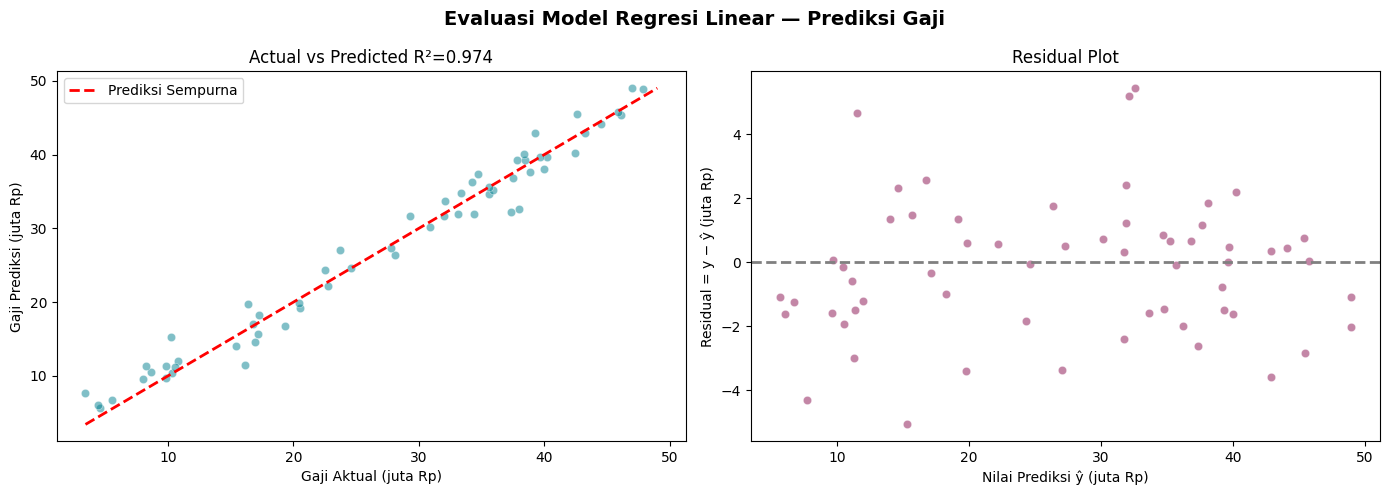

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,
color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2,
label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted R²={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5,
color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')
plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
# Cara membaca Residual Plot:
# ✅ Baik: titik tersebar ACAK di sekitar garis y=0
# ❌ Masalah: ada pola (kurva, corong) → asumsi linearitas dilangga